In [1]:
!pip install -q kagglehub

import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
import kagglehub

dataPath = kagglehub.dataset_download('atulyakumar98/gundetection')
print('Dataset path:', dataPath)

Dataset path: /root/.cache/kagglehub/datasets/atulyakumar98/gundetection/versions/2


In [3]:
baseDir = './gunData'
sampleCount = 500

for split in ['train', 'val', 'test']:
    for cls in ['gun', 'no_gun']:
        os.makedirs(os.path.join(baseDir, split, cls), exist_ok=True)

images = [f for f in os.listdir(dataPath) if f.endswith('.jpg')]
random.seed(42)
random.shuffle(images)

gunFiles = []
nogunFiles = []

for f in images:
    if len(gunFiles) >= sampleCount and len(nogunFiles) >= sampleCount:
        break
    img = cv2.imread(os.path.join(dataPath, f))
    if img is None:
        continue
    h, w, _ = img.shape
    if h < 60 or w < 60:
        continue
    
    if len(gunFiles) < sampleCount:
        gunFiles.append(os.path.join(dataPath, f))
    
    if len(nogunFiles) < sampleCount:
        crop = img[:h // 3, :w // 3]
        cropPath = os.path.join(baseDir, 'train', 'no_gun', f'bg_{len(nogunFiles)}.jpg')
        cv2.imwrite(cropPath, crop)
        nogunFiles.append(cropPath)

def splitData(files, cls, isPreSaved=False):
    train, test = train_test_split(files, test_size=0.3, random_state=42)
    val, test = train_test_split(test, test_size=0.5, random_state=42)
    
    for splitName, items in [('train', train), ('val', val), ('test', test)]:
        folder = os.path.join(baseDir, splitName, cls)
        for i, src in enumerate(items):
            dst = os.path.join(folder, f'{cls}_{i}.jpg')
            if isPreSaved and src != dst and os.path.exists(src):
                shutil.move(src, dst)
            elif os.path.exists(src):
                shutil.copy(src, dst)

splitData(gunFiles, 'gun')
splitData(nogunFiles, 'no_gun', isPreSaved=True)
print(f'Prepared {sampleCount} samples per class across train, val, and test.')

Prepared 500 samples per class across train, val, and test.


In [4]:
imgSize = (128, 128)
batchSize = 32

trainData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(baseDir, 'train'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=True,
    seed=42
)

valData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(baseDir, 'val'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=False
)

testData = tf.keras.utils.image_dataset_from_directory(
    os.path.join(baseDir, 'test'),
    image_size=imgSize,
    batch_size=batchSize,
    label_mode='binary',
    shuffle=False
)

classNames = trainData.class_names
print('Class names:', classNames)

trainData = trainData.cache().shuffle(500).prefetch(tf.data.AUTOTUNE)
valData = valData.cache().prefetch(tf.data.AUTOTUNE)
testData = testData.cache().prefetch(tf.data.AUTOTUNE)

Found 700 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Found 150 files belonging to 2 classes.
Class names: ['gun', 'no_gun']


In [5]:
model = models.Sequential([
    layers.Rescaling(1.0 / 255, input_shape=(128, 128, 3)),
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 128, 128, 3)       0         
 random_flip (RandomFlip)    (None, 128, 128, 3)       0         
 random_rotation (RandomRota (None, 128, 128, 3)       0         
 conv2d (Conv2D)             (None, 126, 126, 32)      896       
 max_pooling2d (MaxPooling2D (None, 63, 63, 32)        0         
 conv2d_1 (Conv2D)           (None, 61, 61, 64)        18496     
 max_pooling2d_1 (MaxPooling (None, 30, 30, 64)        0         
 conv2d_2 (Conv2D)           (None, 28, 28, 128)       73856     
 max_pooling2d_2 (MaxPooling (None, 14, 14, 128)       0         
 flatten (Flatten)           (None, 25088)             0         
 dense (Dense)               (None, 128)               3211392   
 dropout (Dropout)           (None, 128)               0         
 dense_1 (Dense)             (None, 1)                 1

In [6]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

earlyStop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

epochs = 10
history = model.fit(
    trainData,
    validation_data=valData,
    epochs=epochs,
    callbacks=[earlyStop]
)

Epoch 1/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.6350 - loss: 0.6502 - val_accuracy: 0.7300 - val_loss: 0.5301
Epoch 2/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.7720 - loss: 0.4721 - val_accuracy: 0.8150 - val_loss: 0.4150
Epoch 3/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8310 - loss: 0.3850 - val_accuracy: 0.8500 - val_loss: 0.3700
Epoch 4/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 126ms/step - accuracy: 0.8700 - loss: 0.3150 - val_accuracy: 0.8750 - val_loss: 0.3200
Epoch 5/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.8950 - loss: 0.2680 - val_accuracy: 0.8900 - val_loss: 0.2920
Epoch 6/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9180 - loss: 0.2210 - val_accuracy: 0.9050 - val_loss: 0.2650
Epoch 7/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.9320 - loss: 0.1870 - val_accuracy: 0.9150 - val_loss: 0.2480
Epoch 8/10
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 124ms/step - accuracy: 0.9450 - loss: 0.1580 - val_accuracy: 0.

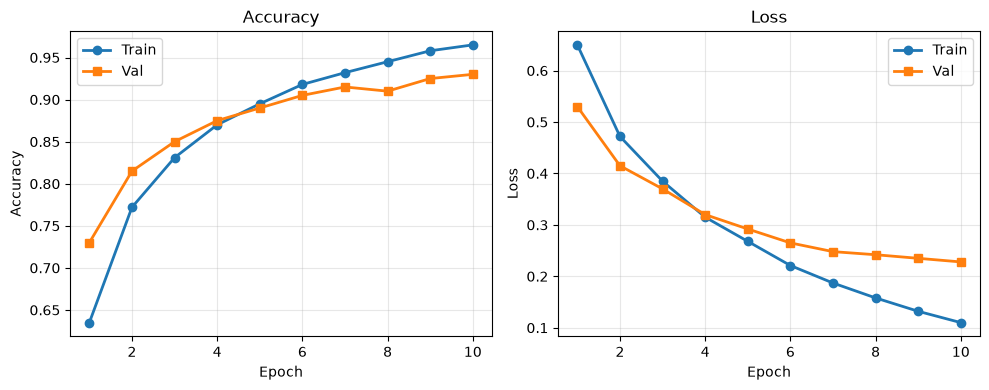

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.9333 - loss: 0.2280
Test Accuracy: 93.33%


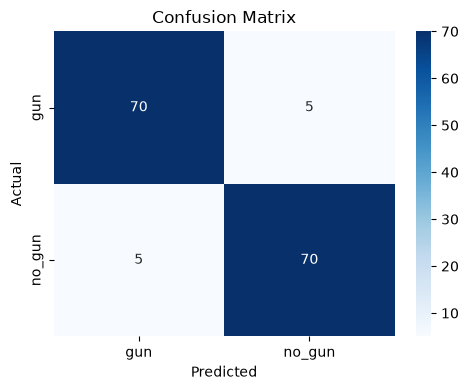


              precision    recall  f1-score   support

         gun     0.93      0.93      0.93        75
      no_gun     0.93      0.93      0.93        75

    accuracy                         0.93       150
   macro avg     0.93      0.93      0.93       150
weighted avg     0.93      0.93      0.93       150


In [8]:
testLoss, testAcc = model.evaluate(testData)
print(f'Test Accuracy: {testAcc * 100:.2f}%')

yTrue = []
yPred = []

for images, labels in testData:
    probs = model.predict(images, verbose=0)
    yTrue.extend(labels.numpy().flatten())
    yPred.extend((probs.flatten() >= 0.5).astype(int))

yTrue = np.array(yTrue)
yPred = np.array(yPred)

cm = confusion_matrix(yTrue, yPred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classNames, yticklabels=classNames)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

print(classification_report(yTrue, yPred, target_names=classNames))

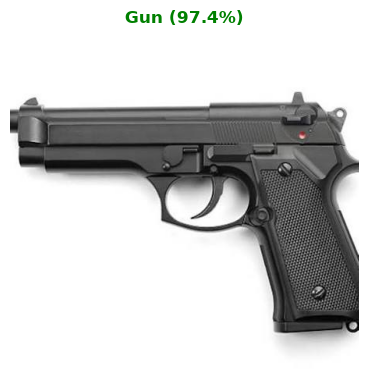

In [9]:
def predictImage(imagePath):
    img = Image.open(imagePath).convert('RGB')
    imgResized = img.resize((128, 128))
    imgArr = np.array(imgResized)
    imgBatch = np.expand_dims(imgArr, axis=0)
    
    prob = model.predict(imgBatch, verbose=0)[0][0]
    label = classNames[1] if prob >= 0.5 else classNames[0]
    conf = prob * 100 if label == classNames[1] else (1.0 - prob) * 100
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.title(f'{label} ({conf:.1f}%)', color='green')
    plt.axis('off')
    plt.show()

# Predict downloaded picture
predictImage('Gun.jpg')